## Part 2 Exercise 5
Function Approximation and Policy Gradient

In [4]:
import random
from collections import deque
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import cookiedisaster

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


#### Inspect data

In [5]:
env = gym.make("cookiedisaster")

state, dist = env.reset()

print(state)
print(dist)

#state shows the info about the agent and the cookie, and the info shows distance between them

{'agent': {'pos': 4, 'vel': 0.0}, 'cookie': {'pos': 0.10111663773625759, 'time': 5}}
{'distance': 3.898883362263742, 'steps': 0}


<frozen importlib._bootstrap>:488: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/nix/store/5n8kjfa10gdbmklvy0s45rpqqc8kkhp9-python3-3.13.12-env/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/nix/store/5n8kjfa10gdbmklvy0s45rpqqc8kkhp9-python3-3.13.12-env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/nix/store/

Info about the environment is given as a nested dict containing info about the agent and the cookies, and the relation between them (dist). For training this info should be made into a flat NumPy array. So make a function to transform it 

In [6]:
def flatten_state(state):
    return np.array([state['agent']["pos"],
                    state['agent']["vel"],
                    state['cookie']["pos"],
                    state['cookie']["time"]
                    ], dtype=np.float32)

def make_env(render_mode=None):
    return gym.make("cookiedisaster", render_mode=render_mode, disable_env_checker=True)

def normalize_state(state):
    agent_pos, agent_vel, cookie_pos, cookie_time = flatten_state(state)
    relative_pos = cookie_pos - agent_pos
    return np.array([
        agent_pos / 10.0,
        np.clip(agent_vel / 6.0, -1.0, 1.0),
        cookie_pos / 10.0,
        cookie_time / 5.0,
        relative_pos / 10.0,
    ], dtype=np.float32)

def linear_features(state):
    agent_pos, agent_vel, cookie_pos, cookie_time = flatten_state(state)
    relative_pos = cookie_pos - agent_pos
    velocity = np.clip(agent_vel / 6.0, -1.0, 1.0)
    return np.array([
        1.0,
        agent_pos / 10.0,
        cookie_pos / 10.0,
        cookie_time / 5.0,
        relative_pos / 10.0,
        abs(relative_pos) / 10.0,
        velocity,
        velocity * (relative_pos / 10.0),
    ], dtype=np.float32)

#example:
flat = flatten_state(state)
print(flat)
print(normalize_state(state))


[4.         0.         0.10111663 5.        ]
[ 0.4         0.          0.01011166  1.         -0.38988835]


#### Parameters

In [7]:
SEED = 123
GAMMA = 0.99
MAX_STEPS = 300
LINEAR_EPISODES = 350
NN_EPISODES = 400
ACTOR_CRITIC_EPISODES = 450
DQN_EPISODES = 450

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Testing visualization (#not right yet, shit crashes)

In [ ]:
vis_test = make_env(render_mode="human")

state, dist = vis_test.reset(seed=SEED)
flatten_state(state)

for i in range(100):
    action = vis_test.action_space.sample()
    state, rewards, terminated, truncated, info = vis_test.step(action)
    if terminated or truncated:
        break

vis_test.close()


#### next steps -> bedre å bruke den project funksjonen i github (neste gang da isåfall)

- normalize the data (remember the velocity change)
- add more params
- use linear approximation (task 2)
    - class?
- use neural network (task 3)
- compare in the report(task 4 (*))
- Figure out visualization
- actor critic (task 5)
  - class actor 
  - class critic
- plot


#### Helper functions


In [8]:
STATE_DIM = len(normalize_state(state))
LINEAR_FEATURE_DIM = len(linear_features(state))
N_ACTIONS = 3


def moving_average(values, window=20):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(values, kernel, mode="valid")


def epsilon_schedule(episode, start=1.0, end=0.05, decay=0.995):
    return max(end, start * (decay ** episode))


def train_agent(agent, episodes, max_steps=MAX_STEPS, epsilon_fn=None, seed=SEED):
    env = make_env()
    history = {"returns": [], "lengths": [], "stats": []}

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0
        epsilon = 0.0 if epsilon_fn is None else epsilon_fn(episode)
        stat = 0.0

        for step in range(max_steps):
            action = agent.act(state, explore=True, epsilon=epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            stat = agent.update(state, action, reward, next_state, done)
            total_reward += reward
            state = next_state
            if done:
                break

        history["returns"].append(total_reward)
        history["lengths"].append(step + 1)
        history["stats"].append(stat)

    env.close()
    return history


@torch.no_grad()
def evaluate_agent(agent, episodes=40, max_steps=MAX_STEPS, seed=SEED):
    env = make_env()
    returns = []

    for episode in range(episodes):
        state, _ = env.reset(seed=10_000 + seed + episode)
        total_reward = 0.0

        for _ in range(max_steps):
            action = agent.act(state, explore=False, epsilon=0.0)
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            state = next_state
            if terminated or truncated:
                break

        returns.append(total_reward)

    env.close()
    return np.asarray(returns, dtype=np.float32)


def plot_history(histories, window=20, title="Training return"):
    plt.figure(figsize=(10, 5))
    for label, values in histories.items():
        averages = moving_average(values, window=window)
        start_index = window - 1 if len(values) >= window else 0
        x = np.arange(len(averages)) + start_index
        plt.plot(x, averages, label=label)

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel(f"Return (moving average, window={window})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def print_evaluation(name, returns):
    print(
        f"{name}: mean={returns.mean():.3f}, std={returns.std():.3f}, "
        f"min={returns.min():.3f}, max={returns.max():.3f}"
    )


#### 2. Linear approximation to approximate qπ(a, s)


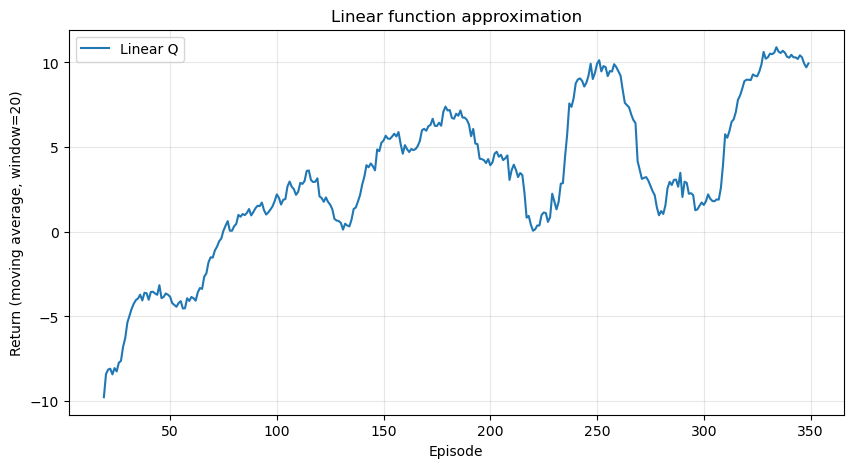

Linear Q: mean=3.586, std=5.209, min=-5.637, max=14.607


In [9]:
class LinearQAgent:
    def __init__(self, feature_dim, n_actions, alpha=0.02, gamma=GAMMA):
        self.feature_dim = feature_dim
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.weights = np.zeros(feature_dim * n_actions, dtype=np.float32)

    def _state_action_features(self, state, action):
        base_features = linear_features(state)
        features = np.zeros(self.feature_dim * self.n_actions, dtype=np.float32)
        start = action * self.feature_dim
        features[start:start + self.feature_dim] = base_features
        return features

    def q_values(self, state):
        return np.array([
            np.dot(self.weights, self._state_action_features(state, action))
            for action in range(self.n_actions)
        ], dtype=np.float32)

    def act(self, state, explore=True, epsilon=0.0):
        if explore and random.random() < epsilon:
            return random.randrange(self.n_actions)
        return int(np.argmax(self.q_values(state)))

    def update(self, state, action, reward, next_state, done):
        features = self._state_action_features(state, action)
        prediction = float(np.dot(self.weights, features))
        target = reward
        if not done:
            target += self.gamma * float(np.max(self.q_values(next_state)))
        td_error = target - prediction
        self.weights += self.alpha * td_error * features
        return td_error


linear_agent = LinearQAgent(LINEAR_FEATURE_DIM, N_ACTIONS)

linear_history = train_agent(
    linear_agent,
    episodes=LINEAR_EPISODES,
    epsilon_fn=lambda episode: epsilon_schedule(episode, start=1.0, end=0.05, decay=0.992),
)

linear_eval = evaluate_agent(linear_agent)
plot_history({"Linear Q": linear_history["returns"]}, title="Linear function approximation")
print_evaluation("Linear Q", linear_eval)


#### 3. Neural network to approximate qπ(a, s)


/nix/store/5n8kjfa10gdbmklvy0s45rpqqc8kkhp9-python3-3.13.12-env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/nix/store/5n8kjfa10gdbmklvy0s45rpqqc8kkhp9-python3-3.13.12-env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


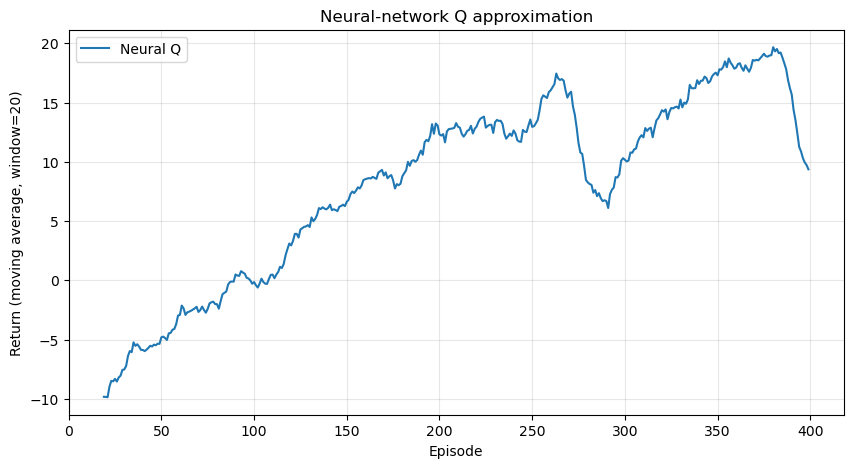

Neural Q: mean=21.282, std=3.377, min=12.348, max=28.000


In [10]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden_dims=(64, 64)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], n_actions),
        )

    def forward(self, x):
        return self.net(x)


class NeuralQAgent:
    def __init__(self, state_dim, n_actions, gamma=GAMMA, lr=1e-3):
        self.n_actions = n_actions
        self.gamma = gamma
        self.q_network = QNetwork(state_dim, n_actions).to(DEVICE)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()

    def _tensor_state(self, state):
        return torch.tensor(normalize_state(state), dtype=torch.float32, device=DEVICE)

    def act(self, state, explore=True, epsilon=0.0):
        if explore and random.random() < epsilon:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            q_values = self.q_network(self._tensor_state(state))
        return int(torch.argmax(q_values).item())

    def update(self, state, action, reward, next_state, done):
        state_tensor = self._tensor_state(state)
        next_state_tensor = self._tensor_state(next_state)

        q_values = self.q_network(state_tensor)
        q_selected = q_values[action]

        with torch.no_grad():
            next_q = self.q_network(next_state_tensor).max()
            target = torch.tensor(reward, dtype=torch.float32, device=DEVICE)
            if not done:
                target = target + self.gamma * next_q

        loss = self.loss_fn(q_selected, target)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), max_norm=5.0)
        self.optimizer.step()
        return float(loss.item())


nn_agent = NeuralQAgent(STATE_DIM, N_ACTIONS)

nn_history = train_agent(
    nn_agent,
    episodes=NN_EPISODES,
    epsilon_fn=lambda episode: epsilon_schedule(episode, start=1.0, end=0.05, decay=0.994),
)

nn_eval = evaluate_agent(nn_agent)
plot_history({"Neural Q": nn_history["returns"]}, title="Neural-network Q approximation")
print_evaluation("Neural Q", nn_eval)


#### 5. Implement actor-critic model


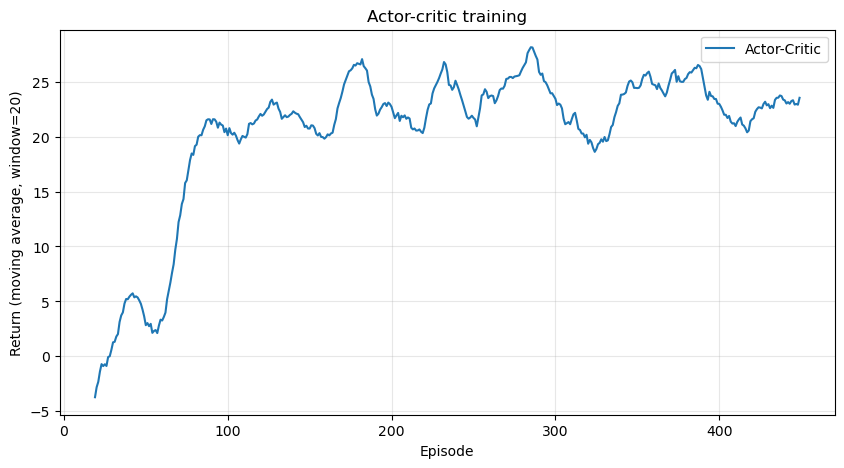

Actor-Critic: mean=27.065, std=5.048, min=9.561, max=36.883


In [11]:
class ActorNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class CriticNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


class ActorCriticAgent:
    def __init__(self, state_dim, n_actions, gamma=GAMMA, actor_lr=3e-4, critic_lr=1e-3, entropy_coef=1e-3):
        self.gamma = gamma
        self.n_actions = n_actions
        self.entropy_coef = entropy_coef
        self.actor = ActorNetwork(state_dim, n_actions).to(DEVICE)
        self.critic = CriticNetwork(state_dim).to(DEVICE)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_lr)

    def _tensor_state(self, state):
        return torch.tensor(normalize_state(state), dtype=torch.float32, device=DEVICE)

    def act(self, state, explore=True, epsilon=0.0):
        state_tensor = self._tensor_state(state)
        with torch.no_grad():
            logits = self.actor(state_tensor)
            probs = torch.softmax(logits, dim=-1)

        if explore:
            return int(torch.multinomial(probs, num_samples=1).item())
        return int(torch.argmax(probs).item())

    def update(self, state, action, reward, next_state, done):
        state_tensor = self._tensor_state(state)
        next_state_tensor = self._tensor_state(next_state)
        action_tensor = torch.tensor(action, dtype=torch.int64, device=DEVICE)

        logits = self.actor(state_tensor)
        dist = torch.distributions.Categorical(logits=logits)
        value = self.critic(state_tensor)

        with torch.no_grad():
            next_value = self.critic(next_state_tensor)
            td_target = torch.tensor(reward, dtype=torch.float32, device=DEVICE)
            if not done:
                td_target = td_target + self.gamma * next_value

        advantage = td_target - value
        actor_loss = -(dist.log_prob(action_tensor) * advantage.detach()) - self.entropy_coef * dist.entropy()
        critic_loss = advantage.pow(2)

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=5.0)
        self.actor_optimizer.step()

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=5.0)
        self.critic_optimizer.step()

        return float(advantage.item())


actor_critic_agent = ActorCriticAgent(STATE_DIM, N_ACTIONS)

actor_critic_history = train_agent(actor_critic_agent, episodes=ACTOR_CRITIC_EPISODES)
actor_critic_eval = evaluate_agent(actor_critic_agent)
plot_history({"Actor-Critic": actor_critic_history["returns"]}, title="Actor-critic training")
print_evaluation("Actor-Critic", actor_critic_eval)


#### 7. Improve solution by adding a replay buffer and target network


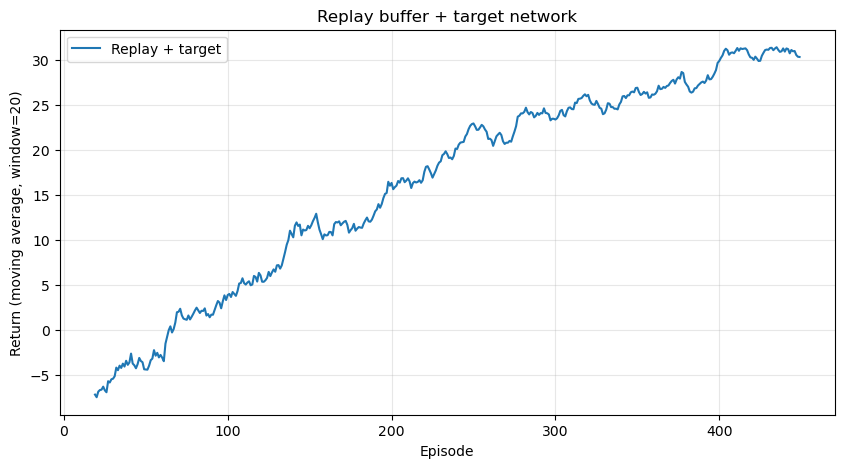

Replay + target: mean=26.394, std=3.964, min=15.787, max=34.171


In [12]:
@dataclass
class Transition:
    state: np.ndarray
    action: int
    reward: float
    next_state: np.ndarray
    done: bool


class ReplayQAgent:
    def __init__(self, state_dim, n_actions, gamma=GAMMA, lr=1e-3, buffer_size=20000, batch_size=64, target_update=200):
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update
        self.online_net = QNetwork(state_dim, n_actions).to(DEVICE)
        self.target_net = QNetwork(state_dim, n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()
        self.replay_buffer = deque(maxlen=buffer_size)
        self.steps = 0

    def _state_array(self, state):
        return normalize_state(state).astype(np.float32)

    def act(self, state, explore=True, epsilon=0.0):
        if explore and random.random() < epsilon:
            return random.randrange(self.n_actions)
        state_tensor = torch.tensor(self._state_array(state), dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            q_values = self.online_net(state_tensor)
        return int(torch.argmax(q_values).item())

    def update(self, state, action, reward, next_state, done):
        self.replay_buffer.append(
            Transition(
                state=self._state_array(state),
                action=action,
                reward=reward,
                next_state=self._state_array(next_state),
                done=done,
            )
        )
        self.steps += 1

        if len(self.replay_buffer) < self.batch_size:
            return 0.0

        batch = random.sample(self.replay_buffer, self.batch_size)
        states = torch.tensor(np.stack([transition.state for transition in batch]), dtype=torch.float32, device=DEVICE)
        actions = torch.tensor([transition.action for transition in batch], dtype=torch.int64, device=DEVICE).unsqueeze(-1)
        rewards = torch.tensor([transition.reward for transition in batch], dtype=torch.float32, device=DEVICE)
        next_states = torch.tensor(np.stack([transition.next_state for transition in batch]), dtype=torch.float32, device=DEVICE)
        dones = torch.tensor([transition.done for transition in batch], dtype=torch.float32, device=DEVICE)

        q_values = self.online_net(states).gather(1, actions).squeeze(-1)
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(dim=1).values
            targets = rewards + self.gamma * next_q_values * (1.0 - dones)

        loss = self.loss_fn(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=5.0)
        self.optimizer.step()

        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return float(loss.item())


dqn_agent = ReplayQAgent(STATE_DIM, N_ACTIONS)

dqn_history = train_agent(
    dqn_agent,
    episodes=DQN_EPISODES,
    epsilon_fn=lambda episode: epsilon_schedule(episode, start=1.0, end=0.05, decay=0.995),
)

dqn_eval = evaluate_agent(dqn_agent)
plot_history({"Replay + target": dqn_history["returns"]}, title="Replay buffer + target network")
print_evaluation("Replay + target", dqn_eval)


#### Comparison plots


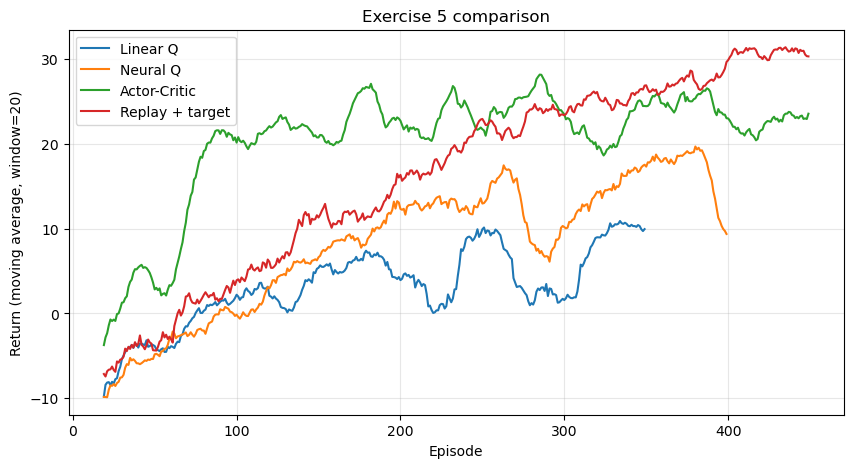

Linear Q: mean=3.586, std=5.209, min=-5.637, max=14.607
Neural Q: mean=21.282, std=3.377, min=12.348, max=28.000
Actor-Critic: mean=27.065, std=5.048, min=9.561, max=36.883
Replay + target: mean=26.394, std=3.964, min=15.787, max=34.171


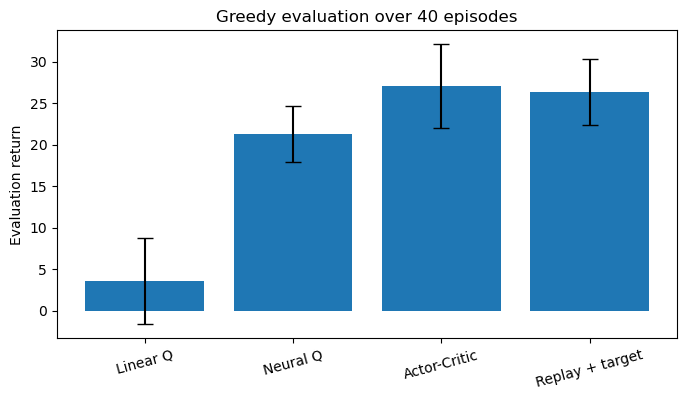

In [13]:
plot_history(
    {
        "Linear Q": linear_history["returns"],
        "Neural Q": nn_history["returns"],
        "Actor-Critic": actor_critic_history["returns"],
        "Replay + target": dqn_history["returns"],
    },
    title="Exercise 5 comparison",
)

comparison = {
    "Linear Q": linear_eval,
    "Neural Q": nn_eval,
    "Actor-Critic": actor_critic_eval,
    "Replay + target": dqn_eval,
}

for name, returns in comparison.items():
    print_evaluation(name, returns)

plt.figure(figsize=(8, 4))
means = [returns.mean() for returns in comparison.values()]
stds = [returns.std() for returns in comparison.values()]
plt.bar(comparison.keys(), means, yerr=stds, capsize=6)
plt.ylabel("Evaluation return")
plt.title("Greedy evaluation over 40 episodes")
plt.xticks(rotation=15)
plt.show()
